# Model Fitting - SEIRS-SEI Model

This notebook demonstrates parameter optimization for the SEIRS-SEI (Susceptible-Exposed-Infectious-Recovered for Humans, Susceptible-Exposed-Infectious for Mosquitoes) model.

## Parameters to Fit

The following parameters will be optimized:
- **T_prime**: Temperature threshold for sporogonic cycle
- **pME**: Probability of egg survival in adult mosquito
- **pML**: Probability of larva survival
- **pMP**: Probability of pupa survival
- **c1**: Larval development rate constant 1
- **c2**: Larval development rate constant 2
- **b1**: Transmission probability (mosquito to human)
- **b2**: Transmission probability (human to mosquito)
- **A**: Temperature-dependent survival parameter A
- **B**: Temperature-dependent survival parameter B
- **C**: Temperature-dependent survival parameter C

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import minimize

from epimodels.continuous import SEIRS_SEI

%matplotlib inline

## Load Data

In [2]:
DATA_PATH = './data/'

START_DATE = '2017-01-01'
END_DATE = '2023-12-31'

# Load climate data
climate_df = pd.read_csv(f'{DATA_PATH}climate_api_data_2016_2024.csv')
climate_df['date'] = pd.to_datetime(climate_df['date'])

# Load cases data
cases_df = pd.read_csv(f'{DATA_PATH}cumulative_manaus_cases_2016_2023.csv')
cases_df['date'] = pd.to_datetime(cases_df['date'])

# Load fire data
fire_df = pd.read_csv(f'{DATA_PATH}inpe_fire_counts_data_2016_2024.csv')
fire_df['date'] = pd.to_datetime(fire_df['date'])

# Load deforestation data
defor_df = pd.read_csv(f'{DATA_PATH}treated_deter_deforestation_data_2016_2024.csv')
defor_df['date'] = pd.to_datetime(defor_df['date'])

# Filter to study period
climate_df = climate_df[
    (climate_df['date'] >= START_DATE) & 
    (climate_df['date'] <= END_DATE)
].reset_index(drop=True)

cases_df = cases_df[
    (cases_df['date'] >= START_DATE) & 
    (cases_df['date'] <= END_DATE)
].reset_index(drop=True)

fire_df = fire_df[
    (fire_df['date'] >= START_DATE) & 
    (fire_df['date'] <= END_DATE)
].reset_index(drop=True)

defor_df = defor_df[
    (defor_df['date'] >= START_DATE) & 
    (defor_df['date'] <= END_DATE)
].reset_index(drop=True)

# Merge all data
climate_df = climate_df.merge(fire_df[['date', 'fire_counts']], on='date', how='left')
climate_df = climate_df.merge(defor_df[['date', 'total_degradation']], on='date', how='left')
climate_df['fire_counts'] = climate_df['fire_counts'].fillna(0)
climate_df['total_degradation'] = climate_df['total_degradation'].fillna(0)

print(f"Climate data shape: {climate_df.shape}")
print(f"Date range: {climate_df['date'].min()} to {climate_df['date'].max()}")
print(f"Cases data shape: {cases_df.shape}")

Climate data shape: (2556, 18)
Date range: 2017-01-01 00:00:00 to 2023-12-31 00:00:00
Cases data shape: (2556, 11)


## Create Interpolation Functions

In [3]:
# Create day number from start
climate_df['day_number'] = (climate_df['date'] - climate_df['date'].min()).dt.days

# Create interpolation functions
temp_interp = interp1d(
    climate_df['day_number'], 
    climate_df['temp_med'],
    kind='linear',
    bounds_error=False,
    fill_value='extrapolate'
)

precip_interp = interp1d(
    climate_df['day_number'],
    climate_df['precip_med'],
    kind='linear',
    bounds_error=False,
    fill_value='extrapolate'
)

umid_interp = interp1d(
    climate_df['day_number'],
    climate_df['umid_med'],
    kind='linear',
    bounds_error=False,
    fill_value='extrapolate'
)

fire_interp = interp1d(
    climate_df['day_number'],
    climate_df['fire_counts'],
    kind='linear',
    bounds_error=False,
    fill_value=0
)

defor_interp = interp1d(
    climate_df['day_number'],
    climate_df['total_degradation'],
    kind='linear',
    bounds_error=False,
    fill_value=0
)

print("Interpolation functions created.")

Interpolation functions created.


## Prepare Time Series Data

In [4]:
# Population parameters
N = 8558  # Human population
M = 100000  # Mosquito population

# Time points
times = climate_df['day_number'].values

# Observed prevalence (active cases)
observed_prevalence = cases_df['active_total'].values.astype(float)

# Initial conditions
I_H0 = float(cases_df['active_total'].iloc[0])
E_H0 = I_H0 * 0.5  # Estimate exposed from infectious
R_H0 = 0
S_H0 = N - E_H0 - I_H0 - R_H0

# Mosquito initial conditions
E_M0 = 10000
I_M0 = 500
S_M0 = M - E_M0 - I_M0

inits = [S_H0, E_H0, I_H0, R_H0, S_M0, E_M0, I_M0]

print(f"Prevalence range: {observed_prevalence.min():.0f} to {observed_prevalence.max():.0f}")
print(f"Time range: {times.min()} to {times.max()} days")
print(f"Initial conditions: S_H0={S_H0:.0f}, E_H0={E_H0:.0f}, I_H0={I_H0:.0f}, R_H0={R_H0:.0f}")

Prevalence range: 410 to 4897
Time range: 0 to 2555 days
Initial conditions: S_H0=5148, E_H0=1136, I_H0=2273, R_H0=0


## Define Parameters

In [5]:
# Fixed parameters (not to be optimized)
fixed_params = {
    # Human disease dynamics
    'gamma': 1/60,  # recovery rate (~60 days)
    'r_H': 0.00005,  # net human growth rate
    'omega': 1/365,  # immunity loss rate (~1 year)
    'tau_H': 10,  # human incubation period (days)
    
    # Mosquito life cycle
    'BE': 200,
    'tauE': 1,
    'tauP': 1,
    'D1': 4.0,
    
    # Sporogonic cycle
    'DD': 105,  # degree-days
    'Tmin': 14.5,
    
    # Larval habitat
    'R_L': 32.67,  # rainfall threshold for breeding
    
    # Environmental modification parameters
    'defor_max_effect': 0.3,
    'defor_scale': 0.0001,
    'defor_delay': 14,
    'fire_smoke_effect': 0.4,
    'fire_habitat_effect': 0.2,
    'fire_recovery_delay': 21,
    
    # Population sizes
    'N': N,
    'M': M
}

# Initial values for parameters to fit
x0 = [25.6, 0.9, 0.25, 0.75, 0.00554, -0.06737, 0.9, 0.9, 12.5, 15.0, -48.78]

# Bounds for parameters
bounds = [
    (15.0, 35.0),    # T_prime
    (0.5, 0.99),     # pME
    (0.1, 0.5),      # pML
    (0.5, 0.9),      # pMP
    (0.001, 0.02),   # c1
    (-0.2, 0.0),     # c2
    (0.5, 0.99),     # b1
    (0.5, 0.99),     # b2
    (5.0, 20.0),     # A
    (10.0, 20.0),    # B
    (-60.0, -30.0),  # C
]

param_names = ['T_prime', 'pME', 'pML', 'pMP', 'c1', 'c2', 'b1', 'b2', 'A', 'B', 'C']

print("Fixed parameters:", list(fixed_params.keys()))
print("Parameters to fit:", param_names)

Fixed parameters: ['gamma', 'r_H', 'omega', 'tau_H', 'BE', 'tauE', 'tauP', 'D1', 'DD', 'Tmin', 'R_L', 'defor_max_effect', 'defor_scale', 'defor_delay', 'fire_smoke_effect', 'fire_habitat_effect', 'fire_recovery_delay', 'N', 'M']
Parameters to fit: ['T_prime', 'pME', 'pML', 'pMP', 'c1', 'c2', 'b1', 'b2', 'A', 'B', 'C']


## Define Loss Function

In [6]:
def loss(x, times, obs_prev, N, M, fixed, inits, param_names, 
         temp_interp, precip_interp, umid_interp, fire_interp, defor_interp):
    """Loss function for optimization."""
    params = {**fixed}
    for name, val in zip(param_names, x):
        params[name] = val
    
    model = SEIRS_SEI(
        temp_func=temp_interp,
        precip_func=precip_interp,
        umid_func=umid_interp,
        fire_func=fire_interp,
        defor_func=defor_interp
    )
    
    try:
        model(
            inits=inits,
            trange=[times.min(), times.max()],
            totpop=N + M,
            params=params,
            validate=False
        )
    except:
        return 1e10
    
    fitted = np.interp(times, model.traces['time'], model.traces['I_H'])
    
    if np.any(np.isnan(fitted)) or np.any(np.isinf(fitted)):
        return 1e10
    
    return np.sum((obs_prev - fitted)**2)

## Run Optimization

In [7]:
print("Running optimization...")
result = minimize(
    loss, 
    x0, 
    args=(
        times, 
        observed_prevalence, 
        N, 
        M, 
        fixed_params, 
        inits, 
        param_names,
        temp_interp, 
        precip_interp, 
        umid_interp, 
        fire_interp, 
        defor_interp
    ),
    method='L-BFGS-B', 
    bounds=bounds,
    options={'maxiter': 100, 'ftol': 1e-6}
)

fitted_params = dict(zip(param_names, result.x))
print(f"\nOptimization Result:")
print(f"Success: {result.success}")
print(f"Loss: {result.fun:.2f}")
print(f"Iterations: {result.nit}")
print(f"\nFitted Parameters:")
for k, v in fitted_params.items():
    print(f"  {k}: {v:.6f}")

Running optimization...

Optimization Result:
Success: True
Loss: 4225634280.48
Iterations: 5

Fitted Parameters:
  T_prime: 25.600001
  pME: 0.900000
  pML: 0.250000
  pMP: 0.750000
  c1: 0.005540
  c2: -0.067370
  b1: 0.900000
  b2: 0.900000
  A: 12.500000
  B: 15.000000
  C: -48.780000


## Run Model with Fitted Parameters

In [8]:
# Combine fixed and fitted parameters
final_params = {**fixed_params, **fitted_params}

# Run model with fitted parameters
fitted_model = SEIRS_SEI(
    temp_func=temp_interp,
    precip_func=precip_interp,
    umid_func=umid_interp,
    fire_func=fire_interp,
    defor_func=defor_interp
)

fitted_model(
    inits=inits,
    trange=[times.min(), times.max()],
    totpop=N + M,
    params=final_params,
    validate=False
)

# Extract fitted I_H
fitted_I_H = np.interp(times, fitted_model.traces['time'], fitted_model.traces['I_H'])

dates = cases_df['date'].values

## Plot Results

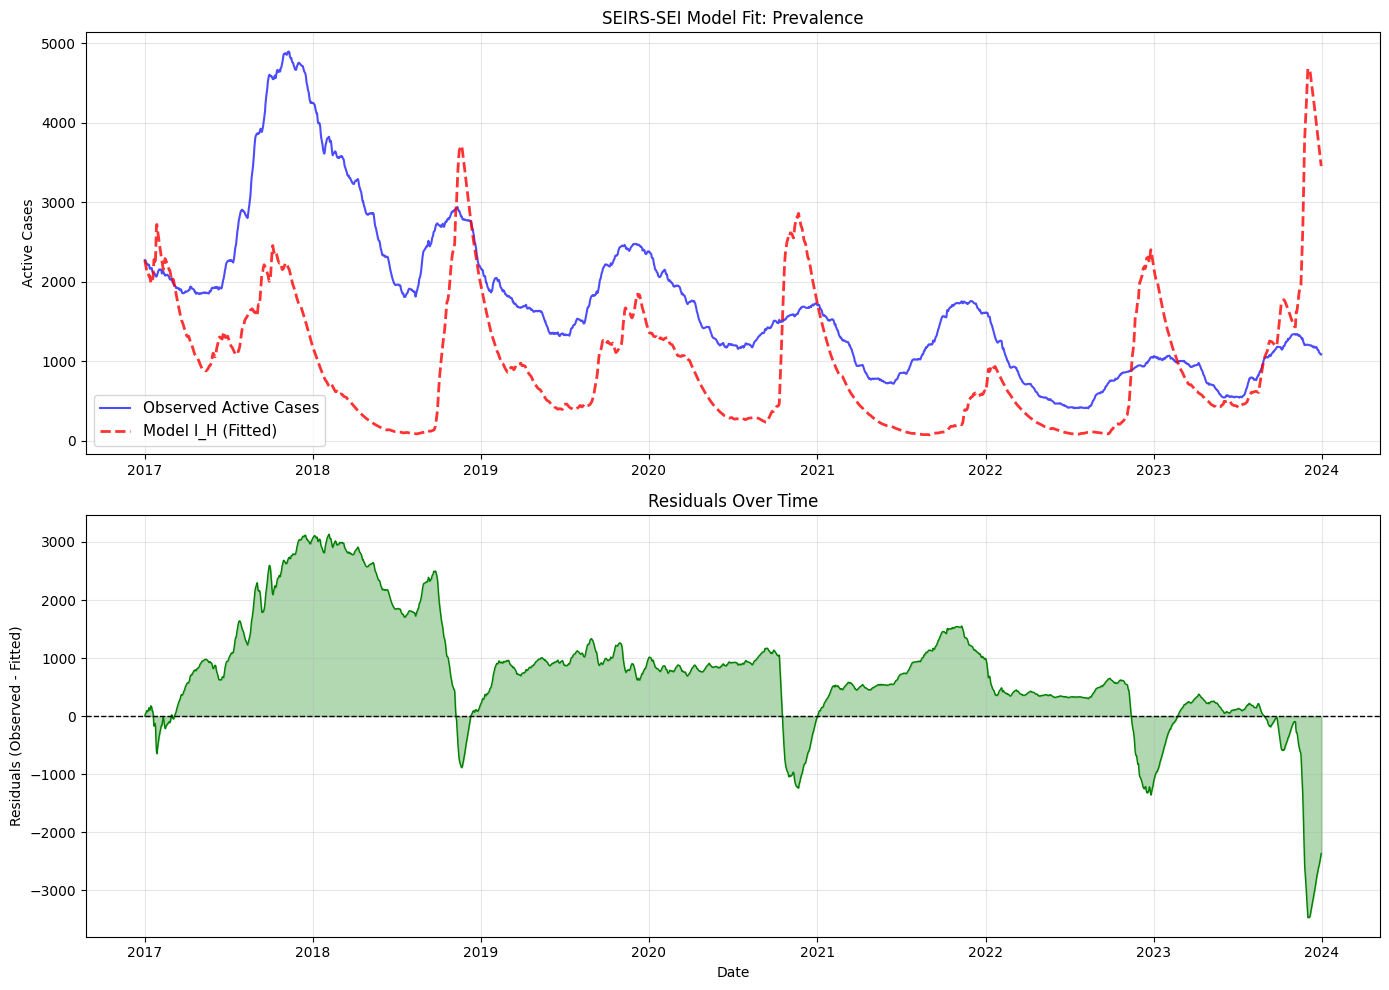

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Observed vs Fitted
axes[0].plot(dates, observed_prevalence, 'b-', alpha=0.7, label='Observed Active Cases', linewidth=1.5)
axes[0].plot(dates, fitted_I_H, 'r--', alpha=0.8, label='Model I_H (Fitted)', linewidth=2)
axes[0].set_ylabel('Active Cases')
axes[0].set_title('SEIRS-SEI Model Fit: Prevalence')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = observed_prevalence - fitted_I_H
axes[1].plot(dates, residuals, 'g-', linewidth=1)
axes[1].axhline(y=0, color='k', linestyle='--', linewidth=1)
axes[1].fill_between(dates, residuals, 0, alpha=0.3, color='green')
axes[1].set_ylabel('Residuals (Observed - Fitted)')
axes[1].set_xlabel('Date')
axes[1].set_title('Residuals Over Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Diagnostics

In [10]:
# Calculate error metrics
rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))

# Pearson correlation
from scipy.stats import pearsonr, spearmanr
pearson_r, pearson_p = pearsonr(observed_prevalence, fitted_I_H)
spearman_r, spearman_p = spearmanr(observed_prevalence, fitted_I_H)

print("="*60)
print("MODEL FIT DIAGNOSTICS")
print("="*60)
print(f"Pearson correlation: {pearson_r:.4f} (p-value: {pearson_p:.2e})")
print(f"Spearman correlation: {spearman_r:.4f} (p-value: {spearman_p:.2e})")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print("="*60)

MODEL FIT DIAGNOSTICS
Pearson correlation: 0.3714 (p-value: 2.03e-84)
Spearman correlation: 0.4669 (p-value: 1.36e-138)
RMSE: 1285.78
MAE: 1000.89


## Compare Initial vs Fitted Model

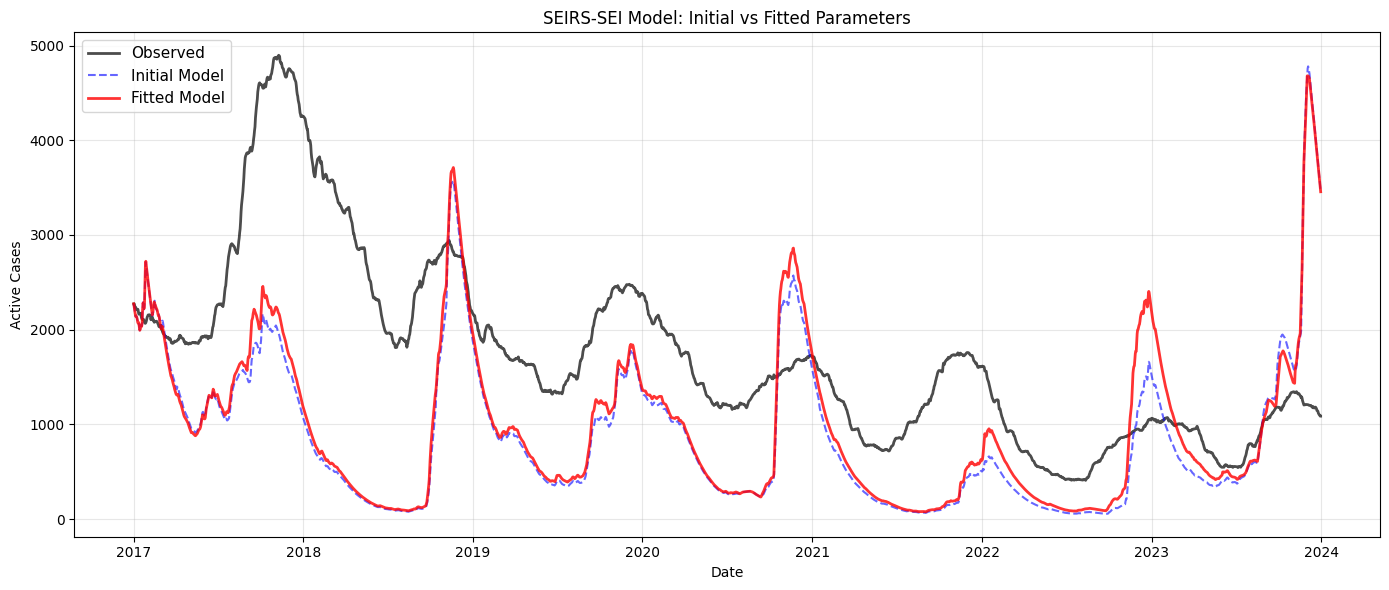


Loss comparison:
  Initial loss: 4503838382.13
  Fitted loss: 4225634280.48
  Improvement: 6.2%


In [11]:
# Run model with initial parameters
initial_params = {**fixed_params}
for name, val in zip(param_names, x0):
    initial_params[name] = val

initial_model = SEIRS_SEI(
    temp_func=temp_interp,
    precip_func=precip_interp,
    umid_func=umid_interp,
    fire_func=fire_interp,
    defor_func=defor_interp
)

initial_model(
    inits=inits,
    trange=[times.min(), times.max()],
    totpop=N + M,
    params=initial_params,
    validate=False
)

initial_I_H = np.interp(times, initial_model.traces['time'], initial_model.traces['I_H'])

# Plot comparison
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates, observed_prevalence, 'k-', alpha=0.7, label='Observed', linewidth=2)
ax.plot(dates, initial_I_H, 'b--', alpha=0.6, label='Initial Model', linewidth=1.5)
ax.plot(dates, fitted_I_H, 'r-', alpha=0.8, label='Fitted Model', linewidth=2)

ax.set_xlabel('Date')
ax.set_ylabel('Active Cases')
ax.set_title('SEIRS-SEI Model: Initial vs Fitted Parameters')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate losses for comparison
initial_loss = np.sum((observed_prevalence - initial_I_H)**2)
fitted_loss = np.sum((observed_prevalence - fitted_I_H)**2)

print(f"\nLoss comparison:")
print(f"  Initial loss: {initial_loss:.2f}")
print(f"  Fitted loss: {fitted_loss:.2f}")
print(f"  Improvement: {(1 - fitted_loss/initial_loss)*100:.1f}%")

## Parameter Summary

In [12]:
# Create summary table
summary_df = pd.DataFrame({
    'Parameter': param_names,
    'Initial': x0,
    'Fitted': [fitted_params[p] for p in param_names],
    'Lower Bound': [b[0] for b in bounds],
    'Upper Bound': [b[1] for b in bounds]
})

summary_df['Change (%)'] = ((summary_df['Fitted'] - summary_df['Initial']) / summary_df['Initial'] * 100).round(2)

print("="*80)
print("PARAMETER SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

PARAMETER SUMMARY
Parameter   Initial     Fitted  Lower Bound  Upper Bound  Change (%)
  T_prime  25.60000  25.600001       15.000        35.00         0.0
      pME   0.90000   0.900000        0.500         0.99        -0.0
      pML   0.25000   0.250000        0.100         0.50         0.0
      pMP   0.75000   0.750000        0.500         0.90        -0.0
       c1   0.00554   0.005540        0.001         0.02        -0.0
       c2  -0.06737  -0.067370       -0.200         0.00         0.0
       b1   0.90000   0.900000        0.500         0.99         0.0
       b2   0.90000   0.900000        0.500         0.99         0.0
        A  12.50000  12.500000        5.000        20.00         0.0
        B  15.00000  15.000000       10.000        20.00         0.0
        C -48.78000 -48.780000      -60.000       -30.00        -0.0


## Save Fitted Parameters

In [13]:
# Save parameters to dictionary
import json

all_params = {**fixed_params, **fitted_params}

print("All model parameters:")
for k, v in all_params.items():
    print(f"  {k}: {v}")

All model parameters:
  gamma: 0.016666666666666666
  r_H: 5e-05
  omega: 0.0027397260273972603
  tau_H: 10
  BE: 200
  tauE: 1
  tauP: 1
  D1: 4.0
  DD: 105
  Tmin: 14.5
  R_L: 32.67
  defor_max_effect: 0.3
  defor_scale: 0.0001
  defor_delay: 14
  fire_smoke_effect: 0.4
  fire_habitat_effect: 0.2
  fire_recovery_delay: 21
  N: 8558
  M: 100000
  T_prime: 25.600000910028633
  pME: 0.8999999984199817
  pML: 0.25000001924311127
  pMP: 0.7499999839313215
  c1: 0.005539971337432968
  c2: -0.06737001778027372
  b1: 0.900000025519731
  b2: 0.9000000313977141
  A: 12.5
  B: 15.0
  C: -48.78
